In [9]:
import pandas as pd
import joblib
import re
import string

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score


In [10]:
# ======================================================
# Text Cleaning Function (MOVE TO TOP ⭐)
# ======================================================
import re
import string

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'\S+@\S+', '', text)
    text = re.sub(r'\d+', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = re.sub(r'\s+', ' ', text).strip()
    return text

In [11]:
# ======================================================
# 1. Load Data
# ======================================================
df = pd.read_csv('C:/Users/Admin/OneDrive/Desktop/Email-Spam App/dataset (1).csv')

# Binary encoding
df['label'] = df['category'].map({'spam': 1, 'not-spam': 0})

print("Class Distribution:")
print(df['label'].value_counts())

Class Distribution:
label
0    1900
1    1896
Name: count, dtype: int64


In [12]:
# ======================================================
# 3. Train/Test Split
# ======================================================
X_train, X_test, y_train, y_test = train_test_split(
    df['email'],
    df['label'],
    test_size=0.2,
    random_state=42,
    stratify=df['label']
)

In [13]:
# ======================================================
# 4. Improved TF-IDF (UPGRADED 🔥)
# ======================================================
tfidf = TfidfVectorizer(
    max_features=20000,
    ngram_range=(1, 3),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True,
    stop_words='english'
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [14]:
# ======================================================
# 5. Model Comparison (IMPORTANT ⭐)
# ======================================================
print("\nModel Comparison:")

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Naive Bayes": MultinomialNB(),
    "Linear SVC": LinearSVC()
}

for name, mdl in models.items():
    mdl.fit(X_train_tfidf, y_train)
    preds = mdl.predict(X_test_tfidf)
    acc = accuracy_score(y_test, preds)
    print(f"{name}: {acc:.4f}")


Model Comparison:
Logistic Regression: 0.9921
Naive Bayes: 0.9697
Linear SVC: 0.9921


In [15]:
# ======================================================
# 6. Hyperparameter Tuning (PRO LEVEL 🚀)
# ======================================================
param_grid = {
    "C": [0.1, 1, 5, 10],
    "solver": ["liblinear"]
}

grid = GridSearchCV(
    LogisticRegression(
        max_iter=1000,
        class_weight="balanced",   # handles imbalance
        random_state=42
    ),
    param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid.fit(X_train_tfidf, y_train)

print("\nBest Params:", grid.best_params_)
print("Best CV Score:", grid.best_score_)

model = grid.best_estimator_


Best Params: {'C': 10, 'solver': 'liblinear'}
Best CV Score: 0.9907770094511402


In [16]:
# ======================================================
# 7. Evaluation
# ======================================================
y_pred = model.predict(X_test_tfidf)

print("\nFinal Model Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# ROC-AUC
probs = model.predict_proba(X_test_tfidf)[:, 1]
print("\nROC-AUC Score:", roc_auc_score(y_test, probs))


Final Model Accuracy: 0.993421052631579

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       380
           1       0.99      0.99      0.99       380

    accuracy                           0.99       760
   macro avg       0.99      0.99      0.99       760
weighted avg       0.99      0.99      0.99       760


Confusion Matrix:
[[378   2]
 [  3 377]]

ROC-AUC Score: 0.9998060941828254


In [17]:
# ======================================================
# 8. Save Model (VERY IMPORTANT)
# ======================================================
joblib.dump(model, "spam_model.pkl")
joblib.dump(tfidf, "tfidf_vectorizer.pkl")

print("\nModel and vectorizer saved!")


Model and vectorizer saved!


In [18]:
def check_email(text, threshold=0.5):
    cleaned = clean_text(text)
    vectorized = tfidf.transform([cleaned])

    prob = model.predict_proba(vectorized)[0][1]
    prediction = 1 if prob >= threshold else 0

    label = "SPAM" if prediction == 1 else "NOT SPAM"
    print(f"Result: {label} ({prob:.2%} spam probability)")

In [19]:
# ======================================================
# 10. Test Examples
# ======================================================
check_email("Congratulations! You've won a $1,000 Walmart gift card. Click here.")
check_email("Hey, are we still meeting for coffee at 4?")

Result: SPAM (70.79% spam probability)
Result: NOT SPAM (40.45% spam probability)


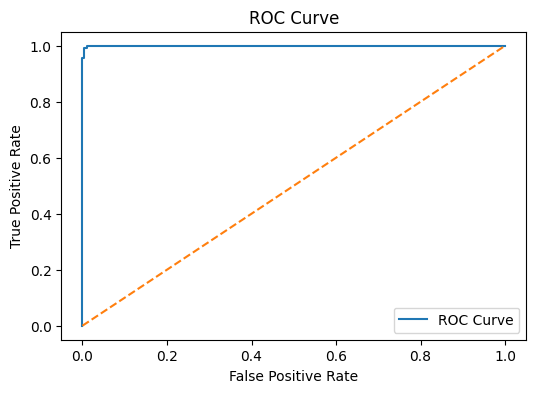

In [20]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(y_test, probs)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label="ROC Curve")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

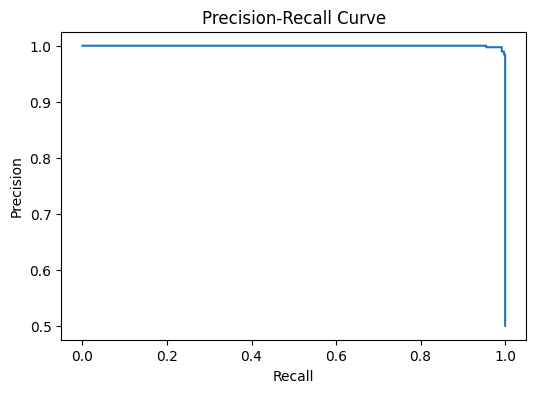

In [21]:
from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(y_test, probs)

plt.figure(figsize=(6,4))
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

In [22]:
import joblib

joblib.dump(model, "spam_model.pkl")
joblib.dump(tfidf, "tfidf_vectorizer.pkl")

print("Files saved successfully!")

Files saved successfully!
